# Ecommify - MongoDB Local en Google Colab

Este notebook crea y usa una instancia MongoDB dentro de Google Colab, sin depender de MongoDB Atlas.

> Nota importante: MongoDB local en Colab es temporal. La base de datos se pierde cuando finaliza la sesión. Para evidencia académica funciona, pero para persistencia real se recomienda MongoDB Atlas.

## Qué hace este notebook

1. Instala MongoDB local en Colab.
2. Inicia el servicio `mongod`.
3. Monta Google Drive.
4. Lee los CSV desde Google Drive.
5. Crea la base de datos `Ecommify`.
6. Crea colecciones.
7. Carga documentos.
8. Crea índices compuestos, parciales y de texto.
9. Ejecuta consultas con `explain("executionStats")`.
10. Ejecuta aggregation pipelines optimizados.
11. Simula sharding y replica set de forma teórica.
12. Genera reportes CSV y HTML.
13. Descarga un ZIP con evidencias.

In [4]:
# ============================================================
# 1. INSTALACIÓN DE DEPENDENCIAS PYTHON
# ============================================================

!pip -q install pymongo pandas numpy matplotlib tabulate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 21.4 MB/s eta 0:00:00


In [1]:
# ============================================================
# 2. INSTALACIÓN DE MONGODB LOCAL EN COLAB
# ============================================================
# Este bloque instala MongoDB Community dentro de la VM temporal de Colab.
# Si Google cambia la imagen base, este bloque puede requerir ajuste.

!apt-get update -qq
!apt-get install -y gnupg curl > /dev/null

# Importar llave pública de MongoDB.
!curl -fsSL https://pgp.mongodb.com/server-7.0.asc | gpg --dearmor -o /usr/share/keyrings/mongodb-server-7.0.gpg

# Registrar repositorio Ubuntu Jammy para MongoDB 7.0.
!echo "deb [ arch=amd64,arm64 signed-by=/usr/share/keyrings/mongodb-server-7.0.gpg ] https://repo.mongodb.org/apt/ubuntu jammy/mongodb-org/7.0 multiverse" | tee /etc/apt/sources.list.d/mongodb-org-7.0.list

!apt-get update -qq
!apt-get install -y mongodb-org > /dev/null

print("MongoDB instalado.")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
deb [ arch=amd64,arm64 signed-by=/usr/share/keyrings/mongodb-server-7.0.gpg ] https://repo.mongodb.org/apt/ubuntu jammy/mongodb-org/7.0 multiverse
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
MongoDB instalado.


In [2]:
# ============================================================
# 3. INICIO DEL SERVICIO MONGODB LOCAL
# ============================================================

import os, subprocess, time, signal, pathlib

db_path = "/content/mongodb_data"
log_path = "/content/mongodb.log"
os.makedirs(db_path, exist_ok=True)

# Iniciar mongod en background.
mongod_process = subprocess.Popen(
    ["mongod", "--dbpath", db_path, "--bind_ip", "127.0.0.1", "--port", "27017", "--logpath", log_path],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

time.sleep(5)

print("Proceso mongod iniciado. PID:", mongod_process.pid)
print("Log:", log_path)

Proceso mongod iniciado. PID: 2548
Log: /content/mongodb.log


In [5]:
# ============================================================
# 4. CONEXIÓN A MONGODB LOCAL
# ============================================================

from pymongo import MongoClient, ASCENDING, DESCENDING, TEXT
from pymongo.errors import ServerSelectionTimeoutError

client = MongoClient("mongodb://127.0.0.1:27017", serverSelectionTimeoutMS=10000)

try:
    print("Versión MongoDB:", client.server_info()["version"])
    print("Conexión exitosa a MongoDB local en Colab")
except ServerSelectionTimeoutError as e:
    raise RuntimeError("No fue posible conectar a MongoDB local en Colab.") from e

db = client["Ecommify"]
print("Base de datos seleccionada:", db.name)

Versión MongoDB: 7.0.37
Conexión exitosa a MongoDB local en Colab
Base de datos seleccionada: Ecommify


In [6]:
# ============================================================
# 5. MONTAJE DE GOOGLE DRIVE
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

# Ruta esperada en Google Drive.
# Crea esta carpeta: Mi unidad/ecommify/csv/
DRIVE_CSV_DIR = "/content/drive/MyDrive/Colab Notebooks/BaseDatosGrupo9"

print("Ruta de CSV configurada:", DRIVE_CSV_DIR)

Mounted at /content/drive
Ruta de CSV configurada: /content/drive/MyDrive/Colab Notebooks/BaseDatosGrupo9


In [7]:
# ============================================================
# 6. CONFIGURACIÓN DE ARCHIVOS CSV
# ============================================================

import os
import pandas as pd
import numpy as np
from pathlib import Path

csv_files = {
    "customers": "olist_customers_dataset.csv",
    "geolocation": "olist_geolocation_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "order_payments": "olist_order_payments_dataset.csv",
    "order_reviews": "olist_order_reviews_dataset.csv",
    "orders": "olist_orders_dataset.csv",
    "products": "olist_products_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "category_translation": "product_category_name_translation.csv",
}

validation_files = []
for name, file in csv_files.items():
    full_path = os.path.join(DRIVE_CSV_DIR, file)
    validation_files.append({
        "dataset": name,
        "archivo": file,
        "ruta": full_path,
        "existe": os.path.exists(full_path)
    })

pd.DataFrame(validation_files)

,dataset,archivo,ruta,existe
0,customers,olist_customers_dataset.csv,/content/drive/MyDrive/Colab Notebooks/BaseDat...,True
1,geolocation,olist_geolocation_dataset.csv,/content/drive/MyDrive/Colab Notebooks/BaseDat...,True
2,order_items,olist_order_items_dataset.csv,/content/drive/MyDrive/Colab Notebooks/BaseDat...,True
3,order_payments,olist_order_payments_dataset.csv,/content/drive/MyDrive/Colab Notebooks/BaseDat...,True
4,order_reviews,olist_order_reviews_dataset.csv,/content/drive/MyDrive/Colab Notebooks/BaseDat...,True
5,orders,olist_orders_dataset.csv,/content/drive/MyDrive/Colab Notebooks/BaseDat...,True
6,products,olist_products_dataset.csv,/content/drive/MyDrive/Colab Notebooks/BaseDat...,True
7,sellers,olist_sellers_dataset.csv,/content/drive/MyDrive/Colab Notebooks/BaseDat...,True
8,category_translation,product_category_name_translation.csv,/content/drive/MyDrive/Colab Notebooks/BaseDat...,True


In [8]:
# ============================================================
# 7. LECTURA DE CSV DESDE GOOGLE DRIVE
# ============================================================

def read_csv_from_drive(key):
    path = os.path.join(DRIVE_CSV_DIR, csv_files[key])
    if not os.path.exists(path):
        raise FileNotFoundError(f"No existe el archivo: {path}")
    return pd.read_csv(path)

customers_df = read_csv_from_drive("customers")
geolocation_df = read_csv_from_drive("geolocation")
order_items_df = read_csv_from_drive("order_items")
order_payments_df = read_csv_from_drive("order_payments")
order_reviews_df = read_csv_from_drive("order_reviews")
orders_df = read_csv_from_drive("orders")
products_df = read_csv_from_drive("products")
sellers_df = read_csv_from_drive("sellers")
category_translation_df = read_csv_from_drive("category_translation")

source_counts = pd.DataFrame([
    ["customers", len(customers_df)],
    ["geolocation", len(geolocation_df)],
    ["order_items", len(order_items_df)],
    ["order_payments", len(order_payments_df)],
    ["order_reviews", len(order_reviews_df)],
    ["orders", len(orders_df)],
    ["products", len(products_df)],
    ["sellers", len(sellers_df)],
    ["category_translation", len(category_translation_df)],
], columns=["fuente", "registros"])

source_counts

,fuente,registros
0,customers,99441
1,geolocation,1000163
2,order_items,112650
3,order_payments,103886
4,order_reviews,99224
5,orders,99441
6,products,32951
7,sellers,3095
8,category_translation,71


In [9]:
# ============================================================
# 8. LIMPIEZA Y NORMALIZACIÓN BÁSICA
# ============================================================

# Corregir typo original del dataset Olist.
products_df = products_df.rename(columns={
    "product_name_lenght": "product_name_length",
    "product_description_lenght": "product_description_length"
})

# Convertir fechas.
date_cols_orders = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
for col in date_cols_orders:
    orders_df[col] = pd.to_datetime(orders_df[col], errors="coerce")

for col in ["review_creation_date", "review_answer_timestamp"]:
    order_reviews_df[col] = pd.to_datetime(order_reviews_df[col], errors="coerce")

order_items_df["shipping_limit_date"] = pd.to_datetime(order_items_df["shipping_limit_date"], errors="coerce")

# Convertir numéricos.
for col in ["price", "freight_value"]:
    order_items_df[col] = pd.to_numeric(order_items_df[col], errors="coerce")

for col in ["payment_value"]:
    order_payments_df[col] = pd.to_numeric(order_payments_df[col], errors="coerce")

for col in ["payment_sequential", "payment_installments"]:
    order_payments_df[col] = pd.to_numeric(order_payments_df[col], errors="coerce")

order_reviews_df["review_score"] = pd.to_numeric(order_reviews_df["review_score"], errors="coerce")

for col in [
    "product_name_length",
    "product_description_length",
    "product_photos_qty",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]:
    products_df[col] = pd.to_numeric(products_df[col], errors="coerce")

print("Limpieza básica finalizada.")

Limpieza básica finalizada.


In [10]:
# ============================================================
# 9. CREACIÓN DE COLECCIONES EN MONGODB LOCAL
# ============================================================

collections = [
    "customers",
    "geolocation",
    "order_items",
    "order_payments",
    "order_reviews",
    "orders",
    "products_catalog",
    "sellers",
    "category_translation",
    "analytics_results"
]

# Se eliminan colecciones previas para permitir reejecución limpia.
for col in collections:
    db[col].drop()
    db.create_collection(col)

print("Colecciones creadas en base de datos Ecommify:")
print(collections)

Colecciones creadas en base de datos Ecommify:
['customers', 'geolocation', 'order_items', 'order_payments', 'order_reviews', 'orders', 'products_catalog', 'sellers', 'category_translation', 'analytics_results']


In [11]:
# ============================================================
# 10. PREPARACIÓN DE DOCUMENTOS DOCUMENTALES
# ============================================================

# Enriquecer productos con traducción de categoría.
products_catalog_df = products_df.merge(
    category_translation_df,
    on="product_category_name",
    how="left"
)

products_catalog_df["product_category_name_english"] = products_catalog_df["product_category_name_english"].fillna(
    products_catalog_df["product_category_name"]
)

# Conversión de NaN/NaT a None.
def clean_for_mongo(df):
    df = df.copy()
    df = df.replace({np.nan: None})
    for col in df.columns:
        if pd.api.types.is_datetime64_any_dtype(df[col]):
            df[col] = df[col].astype(object).where(df[col].notna(), None)
    return df

customers_docs = clean_for_mongo(customers_df).to_dict("records")
geolocation_docs = clean_for_mongo(geolocation_df).to_dict("records")
order_items_docs = clean_for_mongo(order_items_df).to_dict("records")
order_payments_docs = clean_for_mongo(order_payments_df).to_dict("records")
order_reviews_docs = clean_for_mongo(order_reviews_df).to_dict("records")
orders_docs = clean_for_mongo(orders_df).to_dict("records")
products_docs = clean_for_mongo(products_catalog_df).to_dict("records")
sellers_docs = clean_for_mongo(sellers_df).to_dict("records")
category_docs = clean_for_mongo(category_translation_df).to_dict("records")

print("Documentos preparados:")
print("products_catalog:", len(products_docs))
print("orders:", len(orders_docs))
print("order_items:", len(order_items_docs))

Documentos preparados:
products_catalog: 32951
orders: 99441
order_items: 112650


In [12]:
# ============================================================
# 11. CARGA MASIVA DE DATOS A MONGODB LOCAL
# ============================================================

def bulk_insert(collection_name, docs, batch_size=5000):
    col = db[collection_name]
    total = len(docs)
    inserted = 0
    for i in range(0, total, batch_size):
        batch = docs[i:i+batch_size]
        if batch:
            col.insert_many(batch, ordered=False)
            inserted += len(batch)
            print(f"{collection_name}: insertados {inserted}/{total}")
    return inserted

load_results = {
    "customers": bulk_insert("customers", customers_docs),
    "geolocation": bulk_insert("geolocation", geolocation_docs),
    "order_items": bulk_insert("order_items", order_items_docs),
    "order_payments": bulk_insert("order_payments", order_payments_docs),
    "order_reviews": bulk_insert("order_reviews", order_reviews_docs),
    "orders": bulk_insert("orders", orders_docs),
    "products_catalog": bulk_insert("products_catalog", products_docs),
    "sellers": bulk_insert("sellers", sellers_docs),
    "category_translation": bulk_insert("category_translation", category_docs),
}

pd.DataFrame(load_results.items(), columns=["coleccion", "documentos_insertados"])

customers: insertados 5000/99441
customers: insertados 10000/99441
customers: insertados 15000/99441
customers: insertados 20000/99441
customers: insertados 25000/99441
customers: insertados 30000/99441
customers: insertados 35000/99441
customers: insertados 40000/99441
customers: insertados 45000/99441
customers: insertados 50000/99441
customers: insertados 55000/99441
customers: insertados 60000/99441
customers: insertados 65000/99441
customers: insertados 70000/99441
customers: insertados 75000/99441
customers: insertados 80000/99441
customers: insertados 85000/99441
customers: insertados 90000/99441
customers: insertados 95000/99441
customers: insertados 99441/99441
geolocation: insertados 5000/1000163
geolocation: insertados 10000/1000163
geolocation: insertados 15000/1000163
geolocation: insertados 20000/1000163
geolocation: insertados 25000/1000163
geolocation: insertados 30000/1000163
geolocation: insertados 35000/1000163
geolocation: insertados 40000/1000163
geolocation: inser

,coleccion,documentos_insertados
0,customers,99441
1,geolocation,1000163
2,order_items,112650
3,order_payments,103886
4,order_reviews,99224
5,orders,99441
6,products_catalog,32951
7,sellers,3095
8,category_translation,71


In [13]:
# ============================================================
# 12. VALIDACIÓN DE CARGA
# ============================================================

mongo_counts = []
for col in collections:
    mongo_counts.append([col, db[col].count_documents({})])

mongo_counts_df = pd.DataFrame(mongo_counts, columns=["coleccion", "documentos"])
mongo_counts_df

,coleccion,documentos
0,customers,99441
1,geolocation,1000163
2,order_items,112650
3,order_payments,103886
4,order_reviews,99224
5,orders,99441
6,products_catalog,32951
7,sellers,3095
8,category_translation,71
9,analytics_results,0


## 13. Desarrollo de Índices Solicitados

La actividad solicita tres tipos de optimización por índice:

1. Índices compuestos con regla ESR.
2. Índices parciales.
3. Índices de texto para búsqueda full-text.

La regla ESR organiza el índice así:

- Equality: campos consultados por igualdad.
- Sort: campos usados para ordenamiento.
- Range: campos usados para rangos.

In [15]:
# ============================================================
# 13. CREACIÓN DE ÍNDICES
# ============================================================

# Eliminar índices previos distintos a _id_ para permitir reejecución.
for collection_name in ["orders", "order_items", "products_catalog", "order_reviews", "customers", "sellers"]:
    col = db[collection_name]

    for index in list(col.list_indexes()):
        if index["name"] != "_id_":
            try:
                col.drop_index(index["name"])
                print(f"Índice eliminado: {collection_name}.{index['name']}")
            except Exception as e:
                print(f"No se pudo eliminar {collection_name}.{index['name']}: {e}")


# ------------------------------------------------------------
# 1. Índice compuesto ESR para órdenes
# ------------------------------------------------------------
# Equality: order_status
# Sort: order_purchase_timestamp
# Range: order_estimated_delivery_date

db.orders.create_index(
    [
        ("order_status", ASCENDING),
        ("order_purchase_timestamp", DESCENDING),
        ("order_estimated_delivery_date", ASCENDING)
    ],
    name="idx_orders_esr_status_purchase_estimated"
)


# ------------------------------------------------------------
# 2. Índice compuesto para relación lógica orders -> order_items
# ------------------------------------------------------------

db.order_items.create_index(
    [
        ("order_id", ASCENDING),
        ("product_id", ASCENDING),
        ("seller_id", ASCENDING)
    ],
    name="idx_order_items_order_product_seller"
)


# ------------------------------------------------------------
# 3. Índice parcial para catálogo
# ------------------------------------------------------------
# Corrección aplicada:
# En partialFilterExpression MongoDB no permite usar:
# {"$ne": None}
#
# Por eso se reemplaza por:
# {"$type": "string"}
#
# Esto garantiza que solo entren al índice documentos donde
# product_category_name exista y sea texto.

db.products_catalog.create_index(
    [
        ("product_category_name", ASCENDING),
        ("product_weight_g", ASCENDING)
    ],
    name="idx_products_category_weight_partial",
    partialFilterExpression={
        "product_category_name": {"$type": "string"},
        "product_weight_g": {"$gt": 0}
    }
)


# ------------------------------------------------------------
# 4. Índice de texto para búsqueda full-text
# ------------------------------------------------------------

db.products_catalog.create_index(
    [
        ("product_category_name", TEXT),
        ("product_category_name_english", TEXT)
    ],
    name="idx_products_full_text_category"
)


# ------------------------------------------------------------
# 5. Índice para reseñas
# ------------------------------------------------------------

db.order_reviews.create_index(
    [
        ("review_score", ASCENDING),
        ("review_creation_date", DESCENDING)
    ],
    name="idx_reviews_score_creation"
)


# ------------------------------------------------------------
# 6. Índices de apoyo para búsquedas por identificador
# ------------------------------------------------------------

db.customers.create_index(
    [("customer_id", ASCENDING)],
    name="idx_customers_customer_id"
)

db.orders.create_index(
    [("order_id", ASCENDING)],
    name="idx_orders_order_id"
)

db.products_catalog.create_index(
    [("product_id", ASCENDING)],
    name="idx_products_product_id"
)

db.sellers.create_index(
    [("seller_id", ASCENDING)],
    name="idx_sellers_seller_id"
)


# ------------------------------------------------------------
# 7. Evidencia de índices creados
# ------------------------------------------------------------

indexes_created = []

for collection_name in ["orders", "order_items", "products_catalog", "order_reviews", "customers", "sellers"]:
    for index in db[collection_name].list_indexes():
        indexes_created.append({
            "collection": collection_name,
            "index_name": index["name"],
            "key": str(index["key"]),
            "partialFilterExpression": str(index.get("partialFilterExpression", ""))
        })

indexes_df = pd.DataFrame(indexes_created)

indexes_df

Índice eliminado: orders.idx_orders_esr_status_purchase_estimated
Índice eliminado: order_items.idx_order_items_order_product_seller


,collection,index_name,key,partialFilterExpression
0,orders,_id_,"SON([('_id', 1)])",
1,orders,idx_orders_esr_status_purchase_estimated,"SON([('order_status', 1), ('order_purchase_tim...",
2,orders,idx_orders_order_id,"SON([('order_id', 1)])",
3,order_items,_id_,"SON([('_id', 1)])",
4,order_items,idx_order_items_order_product_seller,"SON([('order_id', 1), ('product_id', 1), ('sel...",
5,products_catalog,_id_,"SON([('_id', 1)])",
6,products_catalog,idx_products_category_weight_partial,"SON([('product_category_name', 1), ('product_w...","SON([('product_category_name', SON([('$type', ..."
7,products_catalog,idx_products_full_text_category,"SON([('_fts', 'text'), ('_ftsx', 1)])",
8,products_catalog,idx_products_product_id,"SON([('product_id', 1)])",
9,order_reviews,_id_,"SON([('_id', 1)])",


In [16]:
# ============================================================
# 14. FUNCIONES PARA EXPLAIN EXECUTIONSTATS
# ============================================================

def explain_find(collection, query, sort=None, projection=None, label="query"):
    col = db[collection]
    cursor = col.find(query, projection)
    if sort:
        cursor = cursor.sort(sort)
    stats = cursor.explain()["executionStats"]
    return {
        "label": label,
        "collection": collection,
        "nReturned": stats.get("nReturned"),
        "executionTimeMillis": stats.get("executionTimeMillis"),
        "totalKeysExamined": stats.get("totalKeysExamined"),
        "totalDocsExamined": stats.get("totalDocsExamined"),
        "efficiency_ratio_docs_per_return": round(
            stats.get("totalDocsExamined", 0) / max(stats.get("nReturned", 1), 1), 4
        )
    }

def explain_aggregate(collection, pipeline, label="pipeline"):
    explain_doc = db.command(
        "explain",
        {
            "aggregate": collection,
            "pipeline": pipeline,
            "cursor": {},
            "allowDiskUse": True
        },
        verbosity="executionStats"
    )
    execution_time = explain_doc.get("executionStats", {}).get("executionTimeMillis")
    return {
        "label": label,
        "collection": collection,
        "executionTimeMillis": execution_time,
        "explain_keys": str(list(explain_doc.keys()))
    }

print("Funciones listas.")

Funciones listas.


In [17]:
# ============================================================
# 15. EXPLAIN - ÍNDICE COMPUESTO ESR
# ============================================================

esr_result = explain_find(
    collection="orders",
    query={"order_status": "delivered"},
    sort=[("order_purchase_timestamp", DESCENDING)],
    projection={
        "order_id": 1,
        "customer_id": 1,
        "order_status": 1,
        "order_purchase_timestamp": 1
    },
    label="ESR_orders_delivered_sort_purchase"
)

pd.DataFrame([esr_result])

,label,collection,nReturned,executionTimeMillis,totalKeysExamined,totalDocsExamined,efficiency_ratio_docs_per_return
0,ESR_orders_delivered_sort_purchase,orders,96478,418,96478,96478,1.0


In [18]:
# ============================================================
# 16. EXPLAIN - ÍNDICE PARCIAL
# ============================================================

partial_result = explain_find(
    collection="products_catalog",
    query={
        "product_category_name": "cama_mesa_banho",
        "product_weight_g": {"$gt": 0}
    },
    sort=[("product_weight_g", ASCENDING)],
    projection={
        "product_id": 1,
        "product_category_name": 1,
        "product_weight_g": 1
    },
    label="partial_index_products_category_weight"
)

pd.DataFrame([partial_result])

,label,collection,nReturned,executionTimeMillis,totalKeysExamined,totalDocsExamined,efficiency_ratio_docs_per_return
0,partial_index_products_category_weight,products_catalog,3025,56,0,32951,10.8929


In [19]:
# ============================================================
# 17. EXPLAIN - FULL-TEXT SEARCH
# ============================================================

text_result = explain_find(
    collection="products_catalog",
    query={"$text": {"$search": "bed bath table"}},
    projection={
        "score": {"$meta": "textScore"},
        "product_id": 1,
        "product_category_name": 1,
        "product_category_name_english": 1
    },
    label="full_text_products_search"
)

pd.DataFrame([text_result])

,label,collection,nReturned,executionTimeMillis,totalKeysExamined,totalDocsExamined,efficiency_ratio_docs_per_return
0,full_text_products_search,products_catalog,0,2,0,0,0.0


## 18. Aggregation Pipeline Optimizado

El pipeline cumple con la complejidad mínima solicitada:

- `$match`
- `$project`
- `$lookup`
- `$unwind`
- `$group`
- `$project`
- `$sort`
- `$limit`

Además usa `allowDiskUse=True`.

In [20]:
# ============================================================
# 18. AGGREGATION PIPELINE VENTAS POR CATEGORÍA
# ============================================================

pipeline_sales_by_category = [
    {
        "$match": {
            "order_status": "delivered"
        }
    },
    {
        "$project": {
            "_id": 0,
            "order_id": 1,
            "order_status": 1,
            "order_purchase_timestamp": 1
        }
    },
    {
        "$lookup": {
            "from": "order_items",
            "localField": "order_id",
            "foreignField": "order_id",
            "as": "items"
        }
    },
    {
        "$unwind": "$items"
    },
    {
        "$lookup": {
            "from": "products_catalog",
            "localField": "items.product_id",
            "foreignField": "product_id",
            "as": "product"
        }
    },
    {
        "$unwind": "$product"
    },
    {
        "$group": {
            "_id": "$product.product_category_name_english",
            "orders": {"$addToSet": "$order_id"},
            "items_sold": {"$sum": 1},
            "total_sales": {"$sum": "$items.price"},
            "avg_price": {"$avg": "$items.price"},
            "total_freight": {"$sum": "$items.freight_value"}
        }
    },
    {
        "$project": {
            "_id": 0,
            "category": "$_id",
            "orders_count": {"$size": "$orders"},
            "items_sold": 1,
            "total_sales": {"$round": ["$total_sales", 2]},
            "avg_price": {"$round": ["$avg_price", 2]},
            "total_freight": {"$round": ["$total_freight", 2]},
            "gross_value": {"$round": [{"$add": ["$total_sales", "$total_freight"]}, 2]}
        }
    },
    {
        "$sort": {
            "gross_value": -1
        }
    },
    {
        "$limit": 20
    }
]

sales_by_category = list(db.orders.aggregate(pipeline_sales_by_category, allowDiskUse=True))
sales_by_category_df = pd.DataFrame(sales_by_category)
sales_by_category_df

,items_sold,category,orders_count,total_sales,avg_price,total_freight,gross_value
0,9465,health_beauty,8647,1233131.72,130.28,178957.81,1412089.53
1,5859,watches_gifts,5495,1166176.98,199.04,98156.14,1264333.12
2,10953,bed_bath_table,9272,1023434.76,93.44,201774.50,1225209.26
3,8431,sports_leisure,7530,954852.55,113.25,163404.36,1118256.91
4,7644,computers_accessories,6530,888724.61,116.26,143999.16,1032723.77
5,8160,furniture_decor,6307,711927.69,87.25,168402.23,880329.92
6,6795,housewares,5743,615628.69,90.60,142763.56,758392.25
7,3718,cool_stuff,3559,610204.10,164.12,81476.79,691680.89
8,4140,auto,3810,578966.65,139.85,90488.10,669454.75
9,4268,garden_tools,3448,470495.28,110.24,96650.40,567145.68


In [21]:
# ============================================================
# 19. EXPLAIN DEL PIPELINE OPTIMIZADO
# ============================================================

pipeline_explain = explain_aggregate(
    collection="orders",
    pipeline=pipeline_sales_by_category,
    label="aggregation_sales_by_category_optimized"
)

pd.DataFrame([pipeline_explain])

,label,collection,executionTimeMillis,explain_keys
0,aggregation_sales_by_category_optimized,orders,None,"['explainVersion', 'stages', 'serverInfo', 'se..."


In [22]:
# ============================================================
# 20. PIPELINE CON $FACET Y $BUCKET
# ============================================================

pipeline_facet = [
    {"$match": {"order_status": "delivered"}},
    {"$lookup": {
        "from": "order_items",
        "localField": "order_id",
        "foreignField": "order_id",
        "as": "items"
    }},
    {"$unwind": "$items"},
    {"$facet": {
        "ventas_totales": [
            {"$group": {
                "_id": None,
                "items": {"$sum": 1},
                "venta_total": {"$sum": "$items.price"},
                "flete_total": {"$sum": "$items.freight_value"}
            }},
            {"$project": {
                "_id": 0,
                "items": 1,
                "venta_total": {"$round": ["$venta_total", 2]},
                "flete_total": {"$round": ["$flete_total", 2]}
            }}
        ],
        "top_productos": [
            {"$group": {
                "_id": "$items.product_id",
                "cantidad": {"$sum": 1},
                "venta": {"$sum": "$items.price"}
            }},
            {"$sort": {"venta": -1}},
            {"$limit": 10}
        ],
        "distribucion_precio": [
            {"$bucket": {
                "groupBy": "$items.price",
                "boundaries": [0, 50, 100, 250, 500, 1000, 5000, 15000],
                "default": "otros",
                "output": {
                    "cantidad": {"$sum": 1},
                    "venta": {"$sum": "$items.price"}
                }
            }}
        ]
    }}
]

facet_result = list(db.orders.aggregate(pipeline_facet, allowDiskUse=True))
facet_result

[{'ventas_totales': [{'items': 110197,
    'venta_total': 13221498.11,
    'flete_total': 2198275.64}],
  'top_productos': [{'_id': 'bb50f2e236e5eea0100680137654686c',
    'cantidad': 194,
    'venta': 63560.0},
   {'_id': '6cdd53843498f92890544667809f1595',
    'cantidad': 153,
    'venta': 53652.299999999996},
   {'_id': 'd6160fb7873f184099d9bc95e30376af',
    'cantidad': 33,
    'venta': 45949.35},
   {'_id': 'd1c427060a0f73f6b889a5c7c61f2ac4',
    'cantidad': 332,
    'venta': 45620.56},
   {'_id': '99a4788cb24856965c36a24e339b6058',
    'cantidad': 477,
    'venta': 42049.66},
   {'_id': '3dd2a17168ec895c781a9191c1e95ad7',
    'cantidad': 272,
    'venta': 40782.8},
   {'_id': '25c38557cf793876c5abdd5931f922db',
    'cantidad': 38,
    'venta': 38907.32},
   {'_id': '5f504b3a1c75b73d6151be81eb05bdc9',
    'cantidad': 63,
    'venta': 37733.9},
   {'_id': '53b36df67ebb7c41585e8d54d6772e08',
    'cantidad': 321,
    'venta': 37454.63},
   {'_id': 'aca2eb7d00ea1a7b8ebd4e68314663af',


In [23]:
# ============================================================
# 21. MÉTRICAS CUANTITATIVAS DE RENDIMIENTO
# ============================================================

performance_rows = [esr_result, partial_result, text_result]

performance_rows.append({
    "label": "aggregation_sales_by_category_optimized",
    "collection": "orders",
    "nReturned": len(sales_by_category),
    "executionTimeMillis": pipeline_explain.get("executionTimeMillis"),
    "totalKeysExamined": None,
    "totalDocsExamined": None,
    "efficiency_ratio_docs_per_return": None
})

performance_df = pd.DataFrame(performance_rows)
performance_df

,label,collection,nReturned,executionTimeMillis,totalKeysExamined,totalDocsExamined,efficiency_ratio_docs_per_return
0,ESR_orders_delivered_sort_purchase,orders,96478,418.0,96478.0,96478.0,1.0000
1,partial_index_products_category_weight,products_catalog,3025,56.0,0.0,32951.0,10.8929
2,full_text_products_search,products_catalog,0,2.0,0.0,0.0,0.0000
3,aggregation_sales_by_category_optimized,orders,20,NaN,NaN,NaN,NaN


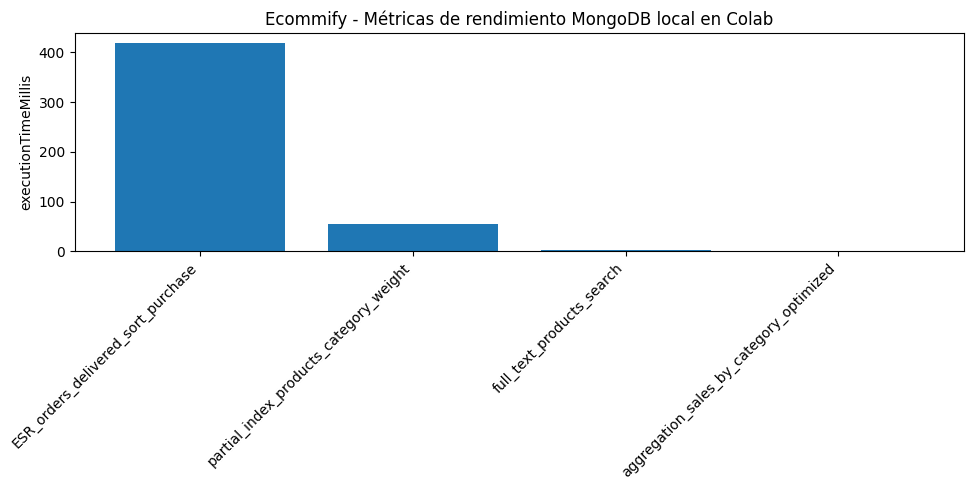

In [24]:
# ============================================================
# 22. GRÁFICA DE TIEMPO DE EJECUCIÓN
# ============================================================

import matplotlib.pyplot as plt

plot_df = performance_df.copy()
plot_df["executionTimeMillis"] = pd.to_numeric(plot_df["executionTimeMillis"], errors="coerce").fillna(0)

plt.figure(figsize=(10, 5))
plt.bar(plot_df["label"], plot_df["executionTimeMillis"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("executionTimeMillis")
plt.title("Ecommify - Métricas de rendimiento MongoDB local en Colab")
plt.tight_layout()
plt.show()

## 23. Diseño Teórico de Sharding y Replica Sets

Como MongoDB en Colab se ejecuta como una instancia local temporal, no se implementa sharding real ni replica set real. Sin embargo, se documenta el diseño propuesto para ambiente productivo.

### Shard Key propuesta para órdenes

```javascript
{ order_status: 1, order_purchase_timestamp: 1 }
```

Justificación:

- Permite filtrar por estado de orden.
- Permite análisis temporal.
- Soporta consultas frecuentes sobre órdenes entregadas, canceladas o en proceso.

### Shard Key propuesta para catálogo

```javascript
{ product_category_name: 1, product_id: 1 }
```

Justificación:

- Las búsquedas de catálogo suelen iniciar por categoría.
- `product_id` incrementa cardinalidad y reduce concentración.

### Replica Set propuesto

- Nodo primario: escrituras.
- Nodo secundario 1: lecturas analíticas.
- Nodo secundario 2: alta disponibilidad y failover.

### Read Concern / Write Concern

- Operaciones críticas: `writeConcern: majority`.
- Analítica: `readConcern: local`.
- Catálogo: lectura desde secundarios cuando aplique.

In [25]:
# ============================================================
# 24. SIMULACIÓN DE DISTRIBUCIÓN DE SHARDS
# ============================================================

orders_sample = orders_df[["order_id", "order_status", "order_purchase_timestamp"]].copy()
orders_sample["year_month"] = orders_sample["order_purchase_timestamp"].dt.strftime("%Y-%m")
orders_sample["simulated_shard"] = orders_sample["order_id"].apply(lambda x: hash(str(x)) % 3)

shard_distribution = orders_sample.groupby("simulated_shard").size().reset_index(name="documents")
shard_distribution["percentage"] = round(shard_distribution["documents"] / shard_distribution["documents"].sum() * 100, 2)

shard_distribution

,simulated_shard,documents,percentage
0,0,33215,33.40
1,1,33217,33.40
2,2,33009,33.19


In [26]:
# ============================================================
# 25. GENERACIÓN AUTOMÁTICA DE REPORTES
# ============================================================

import os
import shutil

REPORT_DIR = "/content/ecommify_reportes_mongodb_local"
os.makedirs(REPORT_DIR, exist_ok=True)

source_counts.to_csv(os.path.join(REPORT_DIR, "01_conteos_fuente.csv"), index=False)
mongo_counts_df.to_csv(os.path.join(REPORT_DIR, "02_conteos_mongodb_local.csv"), index=False)
indexes_df.to_csv(os.path.join(REPORT_DIR, "03_indices_mongodb_local.csv"), index=False)
performance_df.to_csv(os.path.join(REPORT_DIR, "04_metricas_rendimiento.csv"), index=False)
sales_by_category_df.to_csv(os.path.join(REPORT_DIR, "05_ventas_por_categoria.csv"), index=False)
shard_distribution.to_csv(os.path.join(REPORT_DIR, "06_simulacion_sharding.csv"), index=False)

html_report = f'''
<html>
<head>
<meta charset="utf-8">
<title>Informe Ecommify MongoDB Local Colab</title>
<style>
body {{ font-family: Arial, sans-serif; margin: 40px; }}
h1, h2 {{ color: #1f4e79; }}
table {{ border-collapse: collapse; width: 100%; margin-bottom: 24px; }}
th, td {{ border: 1px solid #ccc; padding: 8px; text-align: left; }}
th {{ background-color: #f2f2f2; }}
</style>
</head>
<body>
<h1>Informe Ecommify - Actividad 1 MongoDB Local en Google Colab</h1>

<h2>Resumen Ejecutivo</h2>
<p>Se creó una base de datos MongoDB local dentro de Google Colab para la plataforma Ecommify.
El notebook cargó datos desde Google Drive, creó colecciones documentales, implementó índices compuestos, parciales y de texto,
ejecutó consultas con explain executionStats, desarrolló pipelines de agregación y generó evidencias cuantitativas.</p>

<h2>Conteos de Fuente</h2>
{source_counts.to_html(index=False)}

<h2>Conteos en MongoDB Local</h2>
{mongo_counts_df.to_html(index=False)}

<h2>Índices Implementados</h2>
{indexes_df.to_html(index=False)}

<h2>Métricas de Rendimiento</h2>
{performance_df.to_html(index=False)}

<h2>Top Ventas por Categoría</h2>
{sales_by_category_df.head(20).to_html(index=False)}

<h2>Simulación de Sharding</h2>
{shard_distribution.to_html(index=False)}

<h2>Conclusión</h2>
<p>La implementación cumple los componentes técnicos de la actividad: creación de base documental, carga de datos,
índices ESR, índices parciales, búsqueda full-text, aggregation pipeline de más de cinco etapas, uso de allowDiskUse,
medición con explain y documentación teórica de sharding/replica set.</p>
</body>
</html>
'''

with open(os.path.join(REPORT_DIR, "Informe_Ecommify_MongoDB_Local_Colab.html"), "w", encoding="utf-8") as f:
    f.write(html_report)

zip_report_path = "/content/ecommify_reportes_mongodb_local.zip"
shutil.make_archive("/content/ecommify_reportes_mongodb_local", "zip", REPORT_DIR)

print("Reportes generados en:", REPORT_DIR)
print("ZIP:", zip_report_path)
print(os.listdir(REPORT_DIR))

Reportes generados en: /content/ecommify_reportes_mongodb_local
ZIP: /content/ecommify_reportes_mongodb_local.zip
['05_ventas_por_categoria.csv', '06_simulacion_sharding.csv', '01_conteos_fuente.csv', '03_indices_mongodb_local.csv', 'Informe_Ecommify_MongoDB_Local_Colab.html', '04_metricas_rendimiento.csv', '02_conteos_mongodb_local.csv']


In [27]:
# ============================================================
# 26. DESCARGA DE REPORTES
# ============================================================

from google.colab import files
files.download("/content/ecommify_reportes_mongodb_local.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>